In [ ]:
# installing required libraries
!pip install -q transformers accelerate pillow torch torchvision

In [ ]:
# imports required modules
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch
import requests

device = "cuda" if torch.cuda.is_available() else "cpu"

# defines the pretrained BLIP model name from Hugging Face
model_name = "Salesforce/blip-image-captioning-base"

# loads the processor (handles image preprocessing and decoding)
processor = BlipProcessor.from_pretrained(model_name)

# this loads the pretrained BLIP model and moves it to device
model = BlipForConditionalGeneration.from_pretrained(model_name).to(device)

print("Model loaded on:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Model loaded on: cuda


Example inference (image captioning)

In [ ]:
# this defines a sample image URL
image_url = "https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg"

# this downloads and opens the image
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

# this processes the image into model input tensors
inputs = processor(image, return_tensors="pt").to(device)

# this generates caption without computing gradients
with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=50)

# this decodes the generated tokens into readable text
caption = processor.decode(output[0], skip_special_tokens=True)


print(caption)

a woman sitting on the beach with her dog


Test BLIP on my images

In [ ]:
# here i am importing files tool for uploading images in Colab
from google.colab import files

uploaded = files.upload()

Saving 657121843_1530222768654831_4745892250021103168_n.jpg to 657121843_1530222768654831_4745892250021103168_n.jpg


In [ ]:
# this gets the uploaded image filename
image_path = list(uploaded.keys())[0]

# this opens the uploaded image
image = Image.open(image_path).convert("RGB")

# this prepares the image for BLIP
inputs = processor(image, return_tensors="pt").to(device)

# this generates a caption
with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=50)

caption = processor.decode(output[0], skip_special_tokens=True)
print(caption)

a group of people posing in front of a mural


Dataset

In [ ]:
# i need to connect Google Drive to Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/Shared drives/DATA 298A/DATA/MSVD"

msvd_test.json	msvd_train.json  msvd_val.json	raw_data  raw_videos  README.md


In [ ]:
import json

# this defines paths
msvd_dir = "/content/drive/Shared drives/DATA 298A/DATA/MSVD"
train_json = msvd_dir + "/msvd_train.json"

# this loads training data
with open(train_json, "r") as f:
    train_data = json.load(f)

# this limits to first 50 samples
train_data = train_data[:50]

print("Number of samples:", len(train_data))

Number of samples: 50


In [ ]:
import os

# creates temp folder in Colab
frame_dir = "/content/frames"
os.makedirs(frame_dir, exist_ok=True)

In [ ]:
# this imports cv2
import cv2

# this defines video folder
video_dir = msvd_dir + "/raw_videos"

# this extracts frames from videos
def extract_frames(video_path, video_id, every_n_frames=30):
    cap = cv2.VideoCapture(video_path)
    frame_id = 0
    saved_frames = []

    while True:
        ret, frame = cap.read()

        # stops at end of video
        if not ret:
            break

        # saves every 30th frame
        if frame_id % every_n_frames == 0:
            frame_name = f"{video_id}_{frame_id}.jpg"
            frame_path = os.path.join(frame_dir, frame_name)
            cv2.imwrite(frame_path, frame)
            saved_frames.append(frame_path)

        frame_id += 1

    cap.release()
    return saved_frames

In [ ]:
# this stores image path and caption pairs
dataset = []

# this tracks missing videos
missing_videos = []

for i, item in enumerate(train_data):
    # this prints progress
    print(f"Processing {i+1}/{len(train_data)}")

    # this gets video name
    video_name = item["video"]

    # this gets caption
    caption = item["caption"]

    # this selects the first caption if caption is a list
    if isinstance(caption, list):
        caption = caption[0]

    # this creates full video path
    video_path = os.path.join(video_dir, video_name)

    # this skips missing videos
    if not os.path.exists(video_path):
        missing_videos.append(video_name)
        continue

    # this gets video id
    video_id = os.path.splitext(video_name)[0]

    # this extracts frames
    frames = extract_frames(video_path, video_id, every_n_frames=30)

    # this pairs each frame with one caption
    for f in frames:
        dataset.append((f, caption))

print("Total image-caption pairs:", len(dataset))
print("Missing videos:", len(missing_videos))
print(dataset[:3])

Processing 1/50
Processing 2/50
Processing 3/50
Processing 4/50
Processing 5/50
Processing 6/50
Processing 7/50
Processing 8/50
Processing 9/50
Processing 10/50
Processing 11/50
Processing 12/50
Processing 13/50
Processing 14/50
Processing 15/50
Processing 16/50
Processing 17/50
Processing 18/50
Processing 19/50
Processing 20/50
Processing 21/50
Processing 22/50
Processing 23/50
Processing 24/50
Processing 25/50
Processing 26/50
Processing 27/50
Processing 28/50
Processing 29/50
Processing 30/50
Processing 31/50
Processing 32/50
Processing 33/50
Processing 34/50
Processing 35/50
Processing 36/50
Processing 37/50
Processing 38/50
Processing 39/50
Processing 40/50
Processing 41/50
Processing 42/50
Processing 43/50
Processing 44/50
Processing 45/50
Processing 46/50
Processing 47/50
Processing 48/50
Processing 49/50
Processing 50/50
Total image-caption pairs: 439
Missing videos: 0
[('/content/frames/WTf5EgVY5uU_98_104_0.jpg', 'a woman breaks an egg'), ('/content/frames/WTf5EgVY5uU_98_104_3

In [ ]:
from PIL import Image
import torch

# takes one sample
img_path, caption = dataset[0]

# this loads image
image = Image.open(img_path).convert("RGB")

# this processes image
inputs = processor(image, return_tensors="pt").to(device)

# this generates caption
with torch.no_grad():
    output = model.generate(**inputs)

# this prints results
print("BLIP:", processor.decode(output[0], skip_special_tokens=True))
print("GT:", caption)

BLIP: a woman in a kitchen preparing food
GT: a woman breaks an egg


Fine Tuning

I adapted a pretrained BLIP image captioning model using frames extracted from MSVD videos paired with their captions.


The model was then trained with supervised learning to minimize the difference between its generated captions and the ground truth captions.


This fine-tuning helps the model better align images with MSVD-style descriptions. This improves its captioning performance on similar data.

Total pairs: 439
('/content/frames/WTf5EgVY5uU_98_104_0.jpg', 'a woman breaks an egg')
Missing images: 0


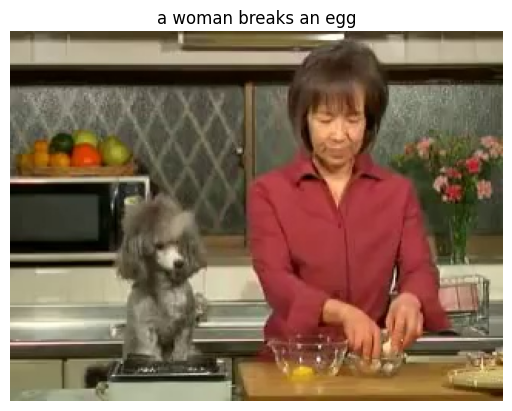

In [ ]:
print("Total pairs:", len(dataset))
print(dataset[0])

# this checks for missing extracted images
missing = [img for img, cap in dataset if not os.path.exists(img)]

# this prints missing count
print("Missing images:", len(missing))


# this previews one frame and caption
import matplotlib.pyplot as plt

img_path, caption = dataset[0]
image = Image.open(img_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.title(caption)
plt.show()

In [ ]:
!pip install -q datasets

In [ ]:
from sklearn.model_selection import train_test_split

# this splits your image-caption pairs
train_pairs, val_pairs = train_test_split(dataset, test_size=0.2, random_state=42)

# this prints split sizes
print("Train pairs:", len(train_pairs))
print("Val pairs:", len(val_pairs))

Train pairs: 351
Val pairs: 88


In [ ]:
from torch.utils.data import Dataset, DataLoader

# this creates a BLIP dataset class with fixed tensor sizes
class BLIPDataset(Dataset):
    def __init__(self, pairs, processor):
        # this stores image-caption pairs
        self.pairs = pairs

        # this stores the BLIP processor
        self.processor = processor

    def __len__(self):
        # this returns dataset length
        return len(self.pairs)

    def __getitem__(self, idx):
        # this gets one image path and caption
        image_path, caption = self.pairs[idx]

        # this opens image
        image = Image.open(image_path).convert("RGB")

        # this processes image and caption with fixed sizes
        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=64,
            return_tensors="pt"
        )

        # this removes extra batch dimension
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}

        # this creates labels from input ids
        labels = encoding["input_ids"].clone()

        # this ignores padding tokens during loss calculation
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        # this adds labels
        encoding["labels"] = labels

        return encoding

In [ ]:
from sklearn.model_selection import train_test_split

# this splits dataset
train_pairs, val_pairs = train_test_split(dataset, test_size=0.2, random_state=42)

# this recreates datasets
train_dataset = BLIPDataset(train_pairs, processor)
val_dataset = BLIPDataset(val_pairs, processor)

# this recreates dataloaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

In [ ]:
# this checks one batch shape
batch = next(iter(train_loader))

# this prints tensor shapes
for k, v in batch.items():
    print(k, v.shape)

pixel_values torch.Size([2, 3, 384, 384])
input_ids torch.Size([2, 64])
attention_mask torch.Size([2, 64])
labels torch.Size([2, 64])


In [ ]:
from torch.optim import AdamW

# this puts model in training mode
model.train()

# this creates optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# this sets number of epochs
num_epochs = 3

# this starts training loop
for epoch in range(num_epochs):
    # this tracks total loss
    total_loss = 0

    # this loops through training batches
    for batch in train_loader:
        # this moves batch to GPU or CPU
        batch = {k: v.to(device) for k, v in batch.items()}

        # this runs model forward pass
        outputs = model(**batch)

        # this gets loss
        loss = outputs.loss

        # this clears old gradients
        optimizer.zero_grad()

        # this backpropagates loss
        loss.backward()

        # this updates model weights
        optimizer.step()

        # this adds loss
        total_loss += loss.item()

    # this prints average epoch loss
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/3, Loss: 1.0005
Epoch 2/3, Loss: 0.1407
Epoch 3/3, Loss: 0.0580


In [ ]:
# this defines save path
save_dir = "/content/blip_msvd_finetuned"

# this saves model
model.save_pretrained(save_dir)

# this saves processor
processor.save_pretrained(save_dir)

# this confirms save
print("Model saved to:", save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/blip_msvd_finetuned


In [ ]:
# this puts model in evaluation mode
model.eval()

# this gets one validation sample
img_path, true_caption = val_pairs[0]

# this opens image
image = Image.open(img_path).convert("RGB")

# this prepares image input
inputs = processor(image, return_tensors="pt").to(device)

# this generates caption
with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=50)

# this decodes generated caption
pred_caption = processor.decode(output[0], skip_special_tokens=True)


print("Predicted:", pred_caption)
print("Ground truth:", true_caption)

Predicted: a woman pours a sauce and some minced substance into a glass bowl containing meat
Ground truth: a woman pours a sauce and some minced substance into a glass bowl containing meat


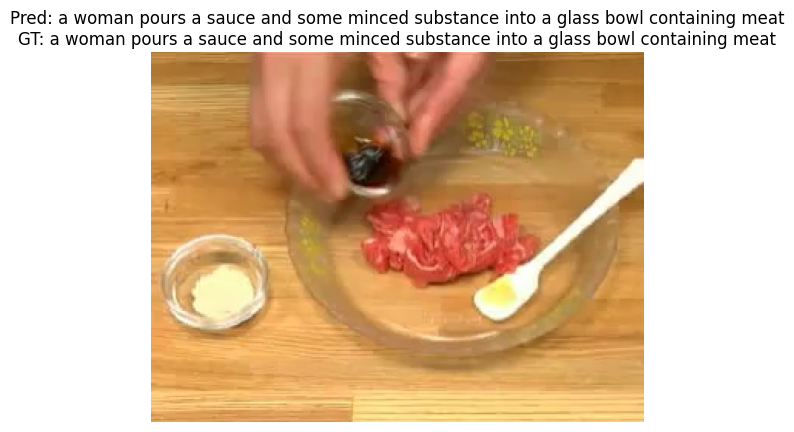

In [ ]:
# this switches model to evaluation mode
model.eval()

# this selects one validation sample
img_path, true_caption = val_pairs[0]

# this loads the image
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(img_path).convert("RGB")

# this prepares input for BLIP
inputs = processor(image, return_tensors="pt").to(device)

# this generates caption
import torch
with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=50)

# this decodes predicted caption
pred_caption = processor.decode(output[0], skip_special_tokens=True)

plt.imshow(image)
plt.axis("off")
plt.title(f"Pred: {pred_caption}\nGT: {true_caption}")
plt.show()

In [ ]:
# this defines final model save path
final_model_dir = "/content/blip_msvd_finetuned_final"

model.save_pretrained(final_model_dir)

# this saves the processor/tokenizer
processor.save_pretrained(final_model_dir)

print("Final model saved at:", final_model_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved at: /content/blip_msvd_finetuned_final


In [ ]:
!cp -r /content/blip_msvd_finetuned_final /content/drive/MyDrive/

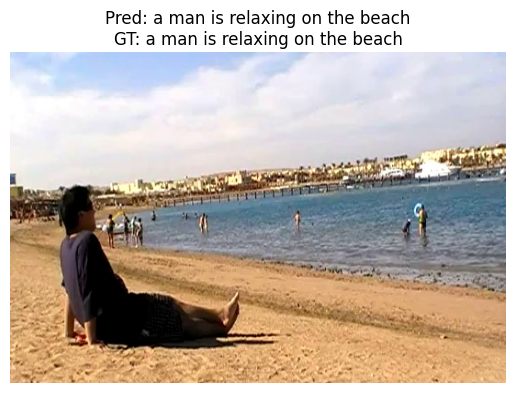

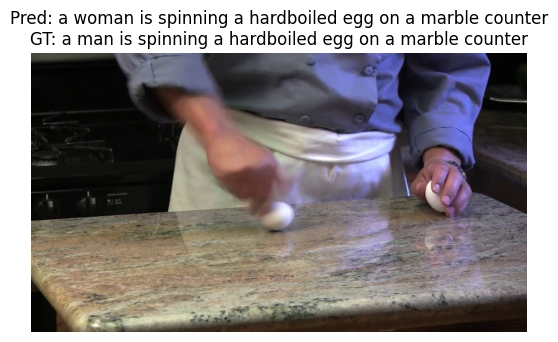

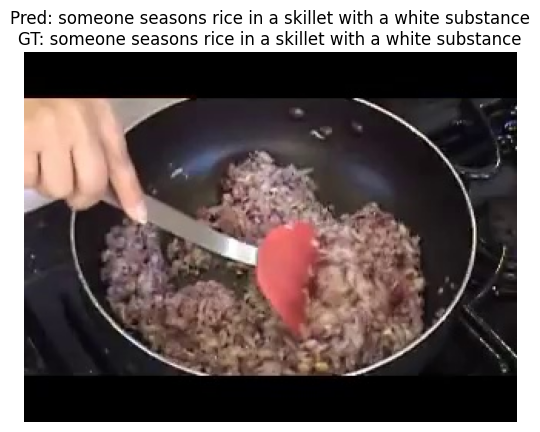

In [25]:
# this switches model to evaluation mode
model.eval()

# this imports needed libraries
from PIL import Image
import matplotlib.pyplot as plt
import torch
import random

# this runs inference on 3 random validation samples
for i in range(3):
    # this picks a random sample
    img_path, true_caption = random.choice(val_pairs)

    # this loads the image
    image = Image.open(img_path).convert("RGB")

    # this prepares input
    inputs = processor(image, return_tensors="pt").to(device)

    # this generates caption (inference step)
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=50)

    # this decodes predicted caption
    pred_caption = processor.decode(output[0], skip_special_tokens=True)

    # this displays image and captions
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Pred: {pred_caption}\nGT: {true_caption}")
    plt.show()